# Spotify Şarkı Analizi

**Yapan:** Ege Yol 24litt010
**Veri seti:** Spotify üzerinden 32833 şarkının özellikleri ve popülerlik bilgileri


Bu çalışmada Spotify'daki binlerce şarkının ses özelliklerini (danceability, energy, valence gibi) ve popülerlik puanlarını analiz ettim. Hangi türler daha popüler, hangi özellikler popülerlikle ilişkili, türler birbirinden nasıl ayrılıyor gibi konulara baktım.

Üç temel bulgu:
1. Pop ve Latin türleri en popüler olanlar
2. Yüksek enerji her zaman yüksek popülerlik demek değil
3. Her tür kendi ses özelliklerine sahip, ayırt etmek mümkün

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Veri Setini Yükleme

Veri seti TidyTuesday projesinden, Spotify API üzerinden derlenmiş.

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
spotify = pd.read_csv(url)

print("Satır sayısı:", spotify.shape[0])
print("Sütun sayısı:", spotify.shape[1])
spotify.head()

Satır sayısı: 32833
Sütun sayısı: 23


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
# Eksik veri kontrolü
print("Eksik değerler:")
print(spotify.isnull().sum().sum(), "tane")

Eksik değerler:
15 tane


## 2. Veri Temizliği

Az miktarda eksik veri var (birkaç şarkı adı boş), onları atıyorum. Bir de aynı şarkı farklı playlistlerde olabiliyor, bunları tekilliyorum.

In [4]:
# Eksik şarkı adı / sanatçı olanları şutla
spotify = spotify.dropna(subset=["track_name", "track_artist"])

# Aynı şarkı tekrarlarını çıkar
spotify = spotify.drop_duplicates(subset=["track_id"])

print("Temizlik sonrası satır sayısı:", spotify.shape[0])

Temizlik sonrası satır sayısı: 28352


## 3. Tanımsal İstatistikler

### Sayısal özelliklerin özeti

In [5]:
sayisal = ["track_popularity", "danceability", "energy", "valence", "tempo", "loudness"]
spotify[sayisal].describe().round(2)

,track_popularity,danceability,energy,valence,tempo,loudness
count,28352.00,28352.00,28352.00,28352.00,28352.00,28352.00
mean,39.34,0.65,0.70,0.51,120.96,-6.82
std,23.70,0.15,0.18,0.23,26.95,3.04
min,0.00,0.00,0.00,0.00,0.00,-46.45
25%,21.00,0.56,0.58,0.33,99.97,-8.31
50%,42.00,0.67,0.72,0.51,121.99,-6.26
75%,58.00,0.76,0.84,0.70,134.00,-4.71
max,100.00,0.98,1.00,0.99,239.44,1.27


### Türlere göre şarkı sayısı

In [6]:
print(spotify["playlist_genre"].value_counts())

playlist_genre
rap      5398
pop      5132
edm      4877
r&b      4504
rock     4305
latin    4136
Name: count, dtype: int64


### Türlere göre ortalama özellikler 

In [7]:
tur_ortalama = spotify.groupby("playlist_genre")[sayisal].mean().round(2)
tur_ortalama

,track_popularity,danceability,energy,valence,tempo,loudness
playlist_genre,,,,,,
edm,30.68,0.66,0.81,0.40,126.33,-5.49
latin,41.45,0.71,0.71,0.61,118.53,-6.48
pop,45.91,0.64,0.70,0.50,120.96,-6.38
r&b,35.93,0.67,0.59,0.54,113.92,-8.03
rap,41.85,0.72,0.65,0.51,120.58,-7.09
rock,39.69,0.52,0.73,0.53,125.04,-7.56


Pop ve latin popülerlikte önde. EDM enerji yüksek ama popülerliği orta. Rock valence olarak en düşük (yani en hüzünlü/yoğun tür).

### Korelasyon matrisi

In [8]:
korelasyon = spotify[sayisal].corr().round(2)
korelasyon

,track_popularity,danceability,energy,valence,tempo,loudness
track_popularity,1.00,0.05,-0.10,0.02,0.00,0.04
danceability,0.05,1.00,-0.08,0.33,-0.18,0.02
energy,-0.10,-0.08,1.00,0.15,0.15,0.68
valence,0.02,0.33,0.15,1.00,-0.03,0.05
tempo,0.00,-0.18,0.15,-0.03,1.00,0.10
loudness,0.04,0.02,0.68,0.05,0.10,1.00


## 4. Grafikler

### Histogram - Popülerlik dağılımı

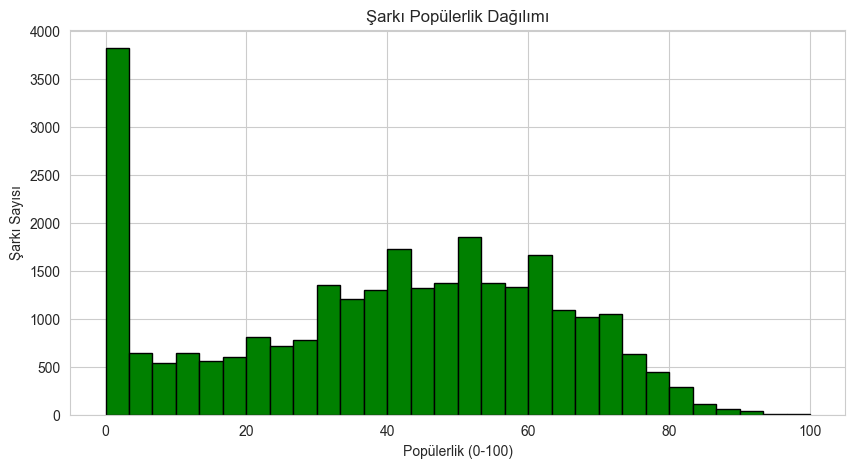

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(spotify["track_popularity"], bins=30, color="green", edgecolor="black")
plt.title("Şarkı Popülerlik Dağılımı")
plt.xlabel("Popülerlik (0-100)")
plt.ylabel("Şarkı Sayısı")
plt.show()

**Yorum:** 0 puana yakın bir yığılma var, sonra 40-70 arasında ana yığın geliyor. 90+ puan alan çok az şarkı var, yani gerçek hit olmak zor.

### Boxplot - Tür bazında popülerlik

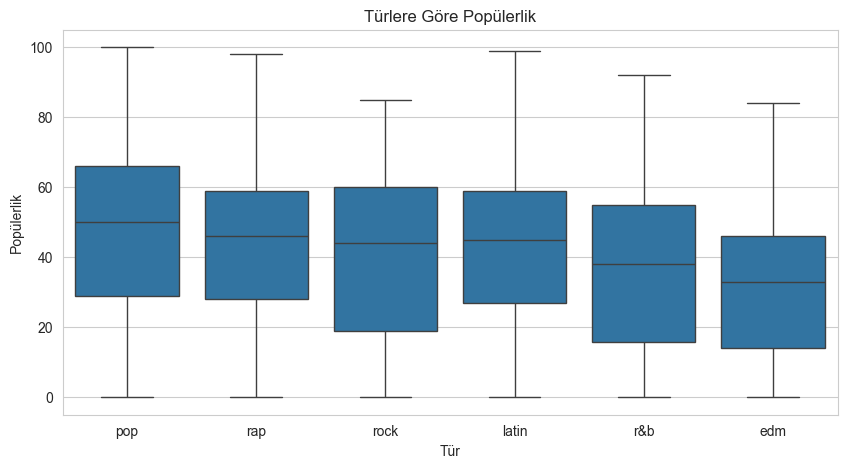

In [10]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=spotify, x="playlist_genre", y="track_popularity")
plt.title("Türlere Göre Popülerlik")
plt.xlabel("Tür")
plt.ylabel("Popülerlik")
plt.show()

**Yorum:** Pop ve latin türlerinin medyanı diğerlerinden bariz yüksek. Rock ve EDM daha düşük. Her türde aykırı değerler var, yani her türde birkaç hit çıkmış.

### Scatter - Danceability vs Energy

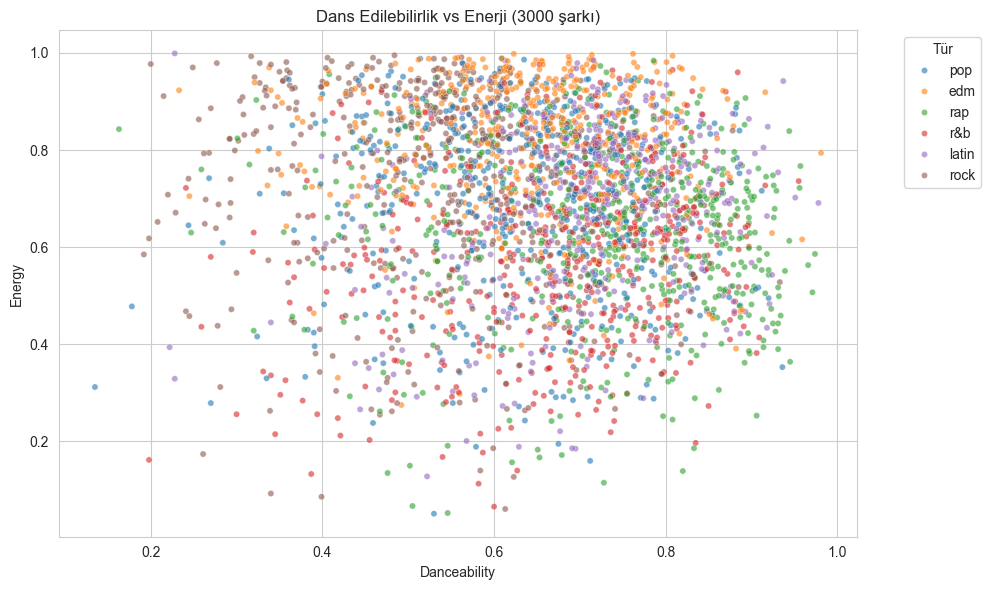

In [11]:
# Çok şarkı var, 3000 örnek alıyorum ki grafik karışmasın
ornek = spotify.sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=ornek, x="danceability", y="energy",
                hue="playlist_genre", alpha=0.6, s=20)
plt.title("Dans Edilebilirlik vs Enerji (3000 şarkı)")
plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.legend(title="Tür", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Yorum:** EDM şarkıları sağ üstte toplanıyor — hem dans edilebilir hem yüksek enerjili. Rock üstte ama sola yakın, enerjik ama dans için değil. Latin ve r&b orta-sağ bölgede.

### Bar - En popüler 10 sanatçı

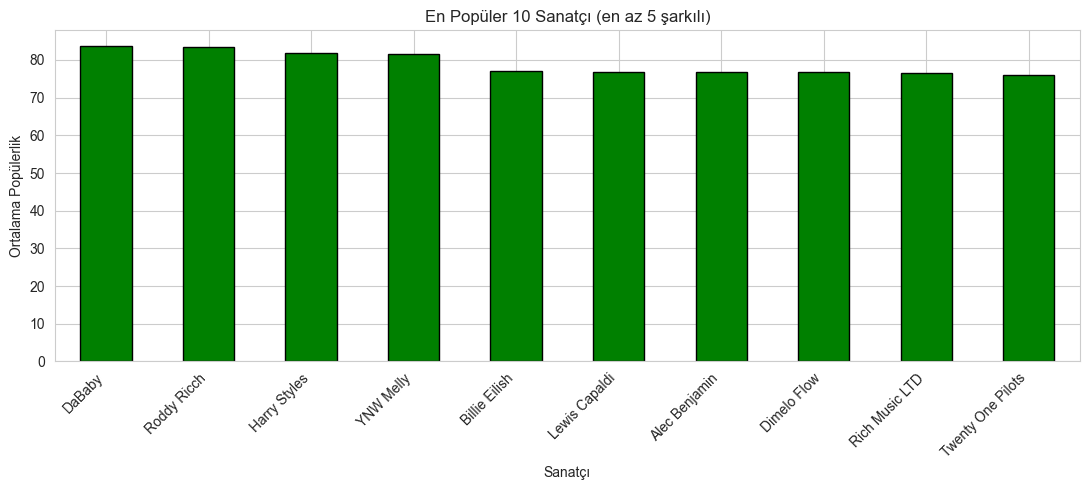

In [12]:
# En az 5 şarkısı olan sanatçılardan en yüksek ortalamalılar
sanatci_ortalama = spotify.groupby("track_artist")["track_popularity"].mean()
sanatci_sayilari = spotify.groupby("track_artist")["track_popularity"].count()
sanatci_tablo = pd.DataFrame({"Ortalama": sanatci_ortalama, "Sayi": sanatci_sayilari})
sanatci_tablo = sanatci_tablo[sanatci_tablo["Sayi"] >= 5]
top_sanatci = sanatci_tablo.sort_values("Ortalama", ascending=False).head(10)

plt.figure(figsize=(11, 5))
top_sanatci["Ortalama"].plot(kind="bar", color="green", edgecolor="black")
plt.title("En Popüler 10 Sanatçı (en az 5 şarkılı)")
plt.xlabel("Sanatçı")
plt.ylabel("Ortalama Popülerlik")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Yorum:** Listede pop ve latin sanatçıları baskın. En az 5 şarkı şartı koyarak tek bir hit'in sanatçıyı listeye sokmasını engelledim.

### Heatmap - Özellikler arası korelasyon

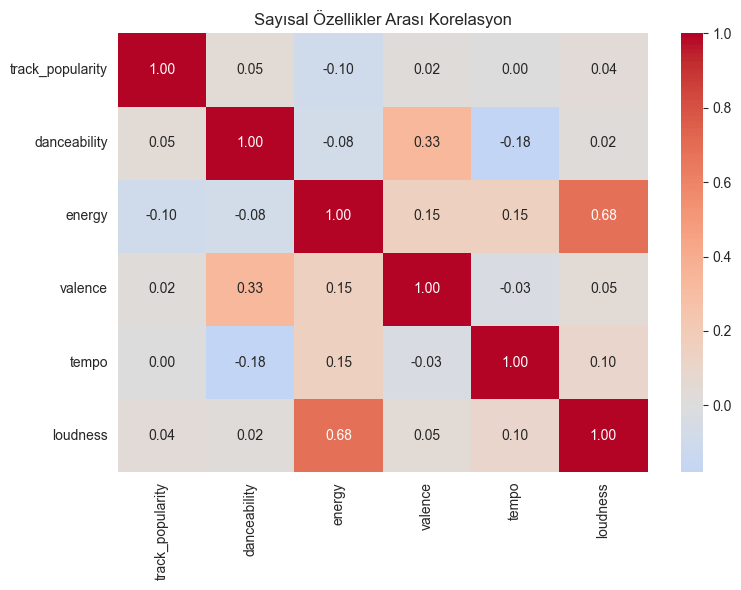

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Sayısal Özellikler Arası Korelasyon")
plt.tight_layout()
plt.show()

**Yorum:** Energy ile loudness arasında güçlü pozitif korelasyon var (~0.68), yani daha enerjik = daha gürültülü. Popülerlik diğer ses özellikleriyle çok zayıf korelasyon gösteriyor, yani sadece "enerjili yap" diyerek popüler şarkı yapılamıyor.

### Etkileşimli grafik - Plotly scatter (Bonus)

In [14]:
fig = px.scatter(ornek, x="valence", y="energy", color="playlist_genre",
                 hover_data=["track_name", "track_artist"],
                 title="Valence (Pozitif Duygu) vs Energy")
fig.update_traces(marker=dict(size=5, opacity=0.6))
fig.show()

**Yorum:** Üzerine gelince şarkının adı ve sanatçısı çıkıyor. EDM yüksek enerji - orta valence bölgesinde, latin yüksek valence + yüksek enerji. R&b ise düşük enerji + düşük valence (daha hüzünlü tarz).

## 5. Bulgular

1. **Pop ve Latin lider.** Popülerlikte bu iki tür diğerlerini açık ara geçiyor. Rock ve EDM daha az popüler ortalama olarak.

2. **Popülerlik karmaşık.** Ses özelliklerine bakarak popülerliği tahmin etmek kolay değil — korelasyonlar düşük. Demek ki bir şarkıyı popüler yapan şey sadece tempo veya enerji değil, başka faktörler de var (sanatçı, pazarlama, vs).

3. **Türler ses imzasıyla ayrılıyor.** Her tür kendine has bir özellik kombinasyonuna sahip: EDM = yüksek enerji + düşük akustik, R&B = düşük enerji + yüksek akustik, Latin = yüksek danceability + yüksek valence.

## 6. Sonuç

Spotify verisi, müziği sayılarla anlamaya çalışmanın hem güçlü hem zayıf yönlerini gösteriyor. Tür ayrımı yapmak için bu özellikler iyi çalışıyor, ama "neden bir şarkı hit olur" sorusu sadece bu verilerle cevaplanamıyor.